# New Zealand Kiwifruit Canopy Area Analysis 2007–2024

This notebook analyses New Zealand kiwifruit canopy area trends from 2007 to 2024 using public data from Stats NZ.

The goal is to understand how green, gold, and other kiwifruit canopy areas have changed over time and what this tells us about the direction of the New Zealand kiwifruit industry.

## 1. Load the Dataset

In this section, we load the kiwifruit canopy area dataset from the `data` folder using Pandas.

The dataset contains canopy area values for green, gold, and other kiwifruit varieties from 2007 to 2024.

In [1]:
from pathlib import Path
import pandas as pd

# Find the dataset file
project_root = Path.cwd()
data_path = project_root / "data" / "kiwifruit_canopy_area.csv"

# Backup path in case VS Code runs the notebook from inside the notebooks folder
if not data_path.exists():
    data_path = project_root.parent / "data" / "kiwifruit_canopy_area.csv"

# Load the dataset
df = pd.read_csv(data_path)

# Display the dataset
df

,year,green_kiwifruit,gold_kiwifruit,other_kiwifruit
0,2007,10500,2300,300
1,2009,10500,2500,300
2,2011,10000,2900,200
3,2012,9500,3100,200
4,2014,7000,3700,300
5,2017,6800,4800,200
6,2019,7800,7000,200
7,2020,7500,7800,300
8,2022,6500,7800,400
9,2024,5600,8200,700


## 2. Create Analysis Columns

In this section, we create new columns to make the dataset more useful for analysis.

We calculate the total canopy area for each year and the percentage share of green, gold, and other kiwifruit varieties.

In [2]:
# Create a copy of the original dataset for analysis
analysis_df = df.copy()

# Calculate total kiwifruit canopy area
analysis_df["total_canopy_area"] = (
    analysis_df["green_kiwifruit"] +
    analysis_df["gold_kiwifruit"] +
    analysis_df["other_kiwifruit"]
)

# Calculate percentage share by variety
analysis_df["green_share_pct"] = (
    analysis_df["green_kiwifruit"] / analysis_df["total_canopy_area"] * 100
).round(2)

analysis_df["gold_share_pct"] = (
    analysis_df["gold_kiwifruit"] / analysis_df["total_canopy_area"] * 100
).round(2)

analysis_df["other_share_pct"] = (
    analysis_df["other_kiwifruit"] / analysis_df["total_canopy_area"] * 100
).round(2)

# Display the updated dataset
analysis_df

,year,green_kiwifruit,gold_kiwifruit,other_kiwifruit,total_canopy_area,green_share_pct,gold_share_pct,other_share_pct
0,2007,10500,2300,300,13100,80.15,17.56,2.29
1,2009,10500,2500,300,13300,78.95,18.80,2.26
2,2011,10000,2900,200,13100,76.34,22.14,1.53
3,2012,9500,3100,200,12800,74.22,24.22,1.56
4,2014,7000,3700,300,11000,63.64,33.64,2.73
5,2017,6800,4800,200,11800,57.63,40.68,1.69
6,2019,7800,7000,200,15000,52.00,46.67,1.33
7,2020,7500,7800,300,15600,48.08,50.00,1.92
8,2022,6500,7800,400,14700,44.22,53.06,2.72
9,2024,5600,8200,700,14500,38.62,56.55,4.83


## 3. Summary Insights

In this section, we calculate the key changes in kiwifruit canopy area from the first year in the dataset to the latest year.

This helps us quickly understand which variety grew, which variety declined, and how the total canopy area changed over time.

In [3]:
# Get first and latest year records
first_year = analysis_df.iloc[0]
latest_year = analysis_df.iloc[-1]

# Calculate changes from first year to latest year
green_change = latest_year["green_kiwifruit"] - first_year["green_kiwifruit"]
gold_change = latest_year["gold_kiwifruit"] - first_year["gold_kiwifruit"]
other_change = latest_year["other_kiwifruit"] - first_year["other_kiwifruit"]
total_change = latest_year["total_canopy_area"] - first_year["total_canopy_area"]

print("NEW ZEALAND KIWIFRUIT CANOPY AREA SUMMARY")
print("----------------------------------------")
print(f"Period analysed: {int(first_year['year'])} to {int(latest_year['year'])}")
print()
print(f"Green kiwifruit changed by: {green_change:,.0f} hectares")
print(f"Gold kiwifruit changed by: {gold_change:,.0f} hectares")
print(f"Other kiwifruit changed by: {other_change:,.0f} hectares")
print(f"Total canopy area changed by: {total_change:,.0f} hectares")
print()
print(f"In {int(latest_year['year'])}:")
print(f"Green share: {latest_year['green_share_pct']}%")
print(f"Gold share: {latest_year['gold_share_pct']}%")
print(f"Other share: {latest_year['other_share_pct']}%")

NEW ZEALAND KIWIFRUIT CANOPY AREA SUMMARY
----------------------------------------
Period analysed: 2007 to 2024

Green kiwifruit changed by: -4,900 hectares
Gold kiwifruit changed by: 5,900 hectares
Other kiwifruit changed by: 400 hectares
Total canopy area changed by: 1,400 hectares

In 2024:
Green share: 38.62%
Gold share: 56.55%
Other share: 4.83%


## 4. Visualize Canopy Area Trends

In this section, we create a line chart to compare green, gold, and other kiwifruit canopy area over time.

This helps us see the long-term industry shift more clearly, especially the decline of green kiwifruit canopy area and the growth of gold kiwifruit canopy area.

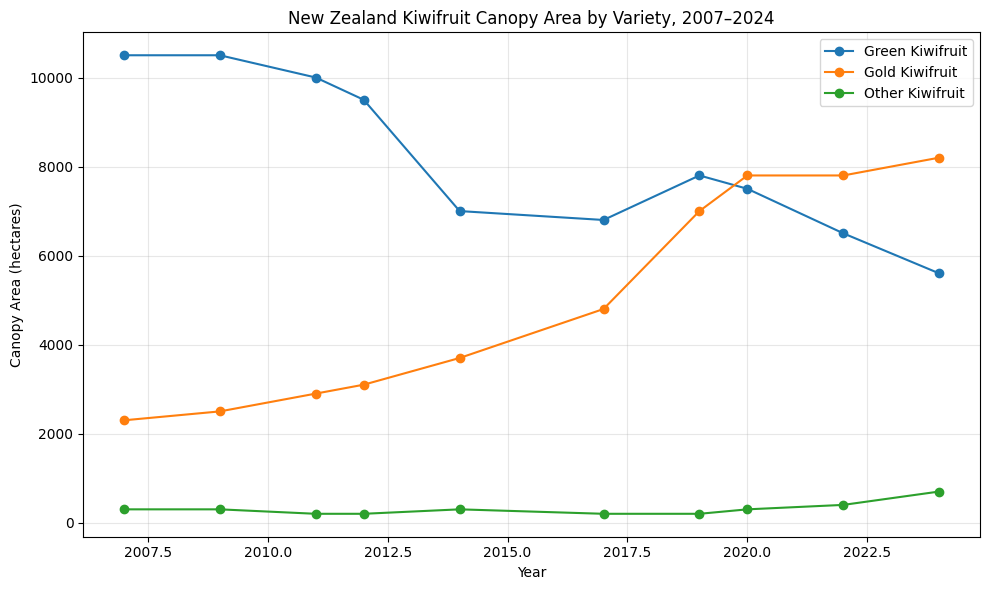

Chart saved to: /home/chrismanlunas/I.T./SCHORT/Projects/nz-kiwifruit-canopy-analysis/visuals/kiwifruit_canopy_area_line_chart.png


In [4]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create the chart
plt.figure(figsize=(10, 6))

plt.plot(analysis_df["year"], analysis_df["green_kiwifruit"], marker="o", label="Green Kiwifruit")
plt.plot(analysis_df["year"], analysis_df["gold_kiwifruit"], marker="o", label="Gold Kiwifruit")
plt.plot(analysis_df["year"], analysis_df["other_kiwifruit"], marker="o", label="Other Kiwifruit")

plt.title("New Zealand Kiwifruit Canopy Area by Variety, 2007–2024")
plt.xlabel("Year")
plt.ylabel("Canopy Area (hectares)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart to visuals folder
project_root = Path.cwd()
visuals_path = project_root / "visuals"

if not visuals_path.exists():
    visuals_path = project_root.parent / "visuals"

visuals_path.mkdir(exist_ok=True)

chart_path = visuals_path / "kiwifruit_canopy_area_line_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Chart saved to: {chart_path}")

## 5. Visualize Percentage Share by Variety

In this section, we create a line chart showing each kiwifruit variety as a percentage of total canopy area.

This helps us understand how the industry mix changed over time, not just the raw hectare numbers.

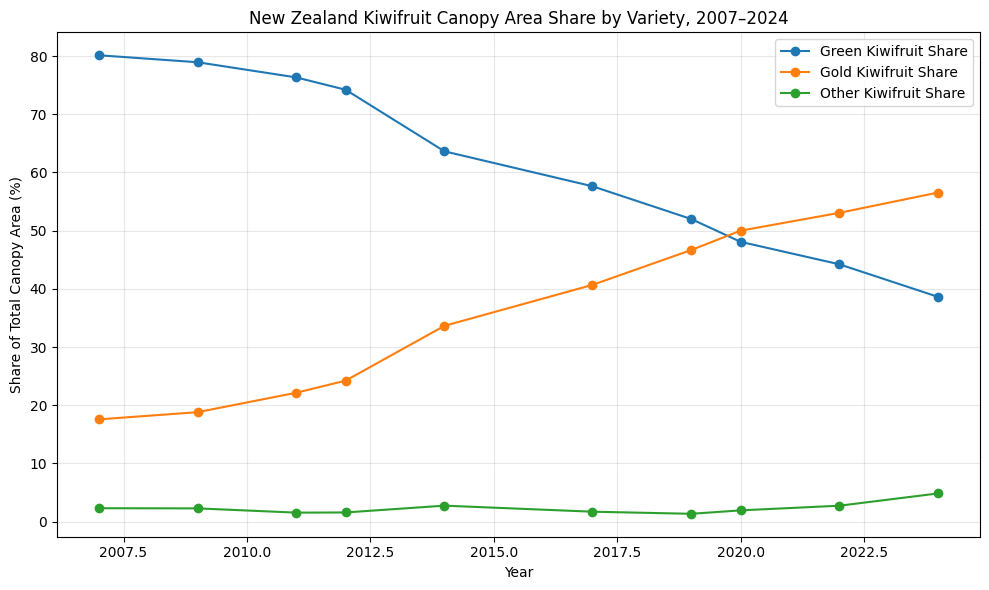

Chart saved to: /home/chrismanlunas/I.T./SCHORT/Projects/nz-kiwifruit-canopy-analysis/visuals/kiwifruit_canopy_area_share_chart.png


In [5]:
# Create percentage share chart
plt.figure(figsize=(10, 6))

plt.plot(analysis_df["year"], analysis_df["green_share_pct"], marker="o", label="Green Kiwifruit Share")
plt.plot(analysis_df["year"], analysis_df["gold_share_pct"], marker="o", label="Gold Kiwifruit Share")
plt.plot(analysis_df["year"], analysis_df["other_share_pct"], marker="o", label="Other Kiwifruit Share")

plt.title("New Zealand Kiwifruit Canopy Area Share by Variety, 2007–2024")
plt.xlabel("Year")
plt.ylabel("Share of Total Canopy Area (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart to visuals folder
chart_path = visuals_path / "kiwifruit_canopy_area_share_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Chart saved to: {chart_path}")

## 6. Visualize Total Canopy Area by Variety

In this section, we create a stacked bar chart showing total kiwifruit canopy area by variety.

This helps us see both the total industry size and how green, gold, and other kiwifruit contribute to the overall canopy area each year.

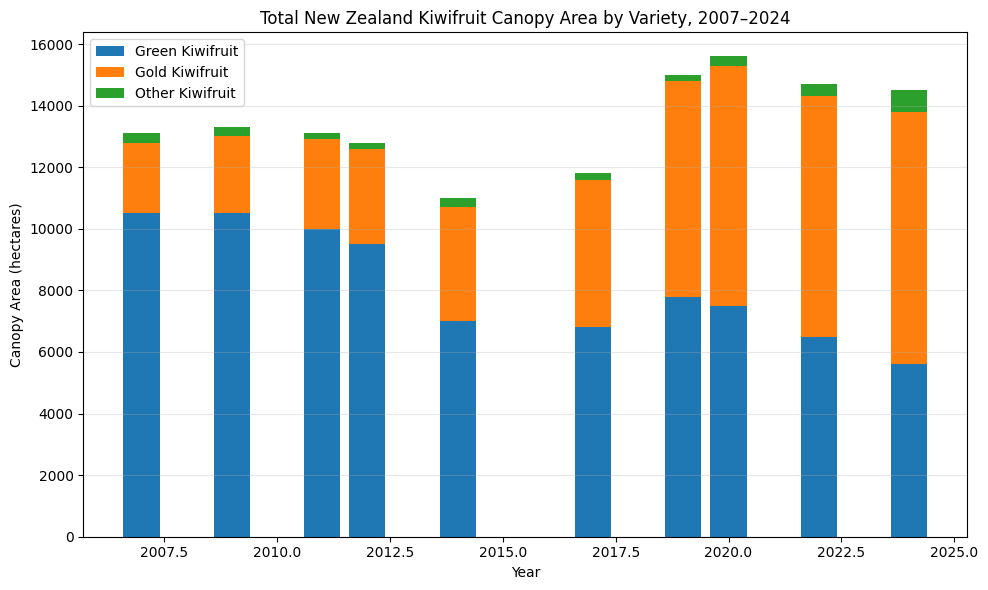

Chart saved to: /home/chrismanlunas/I.T./SCHORT/Projects/nz-kiwifruit-canopy-analysis/visuals/kiwifruit_canopy_area_stacked_bar_chart.png


In [6]:
# Create stacked bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    analysis_df["year"],
    analysis_df["green_kiwifruit"],
    label="Green Kiwifruit"
)

plt.bar(
    analysis_df["year"],
    analysis_df["gold_kiwifruit"],
    bottom=analysis_df["green_kiwifruit"],
    label="Gold Kiwifruit"
)

plt.bar(
    analysis_df["year"],
    analysis_df["other_kiwifruit"],
    bottom=analysis_df["green_kiwifruit"] + analysis_df["gold_kiwifruit"],
    label="Other Kiwifruit"
)

plt.title("Total New Zealand Kiwifruit Canopy Area by Variety, 2007–2024")
plt.xlabel("Year")
plt.ylabel("Canopy Area (hectares)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save chart to visuals folder
chart_path = visuals_path / "kiwifruit_canopy_area_stacked_bar_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Chart saved to: {chart_path}")

## 7. Save the Processed Dataset

In this section, we save the cleaned and analysis-ready dataset into a new CSV file.

This keeps the original dataset unchanged while giving us a processed version that includes total canopy area and percentage share columns.

In [7]:
# Save the analysis-ready dataset
processed_data_path = data_path.parent / "kiwifruit_canopy_area_processed.csv"

analysis_df.to_csv(processed_data_path, index=False)

print(f"Processed dataset saved to: {processed_data_path}")

Processed dataset saved to: /home/chrismanlunas/I.T./SCHORT/Projects/nz-kiwifruit-canopy-analysis/data/kiwifruit_canopy_area_processed.csv
